In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [2]:
df = pd.read_csv(r"C:\Users\Pooja\Downloads\CARBON_PREDICTION\owid-co2-data.csv")
df.head()

,iso_code,country,year,co2,co2_per_capita,trade_co2,cement_co2,cement_co2_per_capita,coal_co2,coal_co2_per_capita,...,ghg_excluding_lucf_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,0.002,NaN,NaN,NaN,0.015,0.002,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,0.011,NaN,NaN,NaN,0.021,0.003,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,0.012,NaN,NaN,NaN,0.026,0.003,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,0.012,NaN,NaN,NaN,0.032,0.004,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001733e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,0.013,NaN,NaN,NaN,0.038,0.005,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25989 entries, 0 to 25988
Data columns (total 60 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   iso_code                             21960 non-null  object 
 1   country                              25989 non-null  object 
 2   year                                 25989 non-null  int64  
 3   co2                                  24670 non-null  float64
 4   co2_per_capita                       24032 non-null  float64
 5   trade_co2                            4096 non-null   float64
 6   cement_co2                           12668 non-null  float64
 7   cement_co2_per_capita                12638 non-null  float64
 8   coal_co2                             17909 non-null  float64
 9   coal_co2_per_capita                  17536 non-null  float64
 10  flaring_co2                          4641 non-null   float64
 11  flaring_co2_per_capita      

,year,co2,co2_per_capita,trade_co2,cement_co2,cement_co2_per_capita,coal_co2,coal_co2_per_capita,flaring_co2,flaring_co2_per_capita,...,ghg_excluding_lucf_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
count,25989.000000,24670.000000,24032.000000,4096.000000,12668.000000,12638.000000,17909.000000,17536.000000,4641.000000,4640.000000,...,5651.000000,5655.000000,5655.000000,5655.000000,5655.000000,2.289200e+04,1.346900e+04,9345.000000,9300.000000,7149.000000
mean,1952.168225,326.658348,4.115845,-8.124470,15.853638,0.111586,212.296783,1.543364,17.691973,0.829055,...,6.870665,79.072368,1.902152,29.088635,0.601973,7.068041e+07,2.889570e+11,1425.651569,24469.973841,1.805888
std,54.592939,1677.027130,14.700552,262.090605,84.179826,0.147534,863.287148,2.524852,42.421165,5.326217,...,7.270324,545.014528,3.318293,198.147748,0.890161,3.794737e+08,2.185600e+12,8750.538123,32096.347648,1.779325
min,1750.000000,0.000000,0.000000,-2232.999000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.101000,0.000000,0.000000,0.000000,0.000000,1.490000e+03,5.543200e+07,0.000000,0.000000,0.078000
25%,1922.000000,0.557000,0.253000,-1.663750,0.134000,0.019000,0.359000,0.056000,0.288000,0.020000,...,2.095500,2.005000,0.691000,0.510000,0.221000,1.287425e+06,9.790110e+09,6.440000,3067.494750,0.859000
50%,1966.000000,5.333000,1.226000,1.874500,0.603000,0.068000,4.540000,0.441500,2.396000,0.064000,...,4.442000,8.530000,1.077000,3.460000,0.377000,4.869928e+06,3.044678e+10,54.352000,12983.272000,1.309000
75%,1994.000000,48.153250,4.612250,9.700500,3.255000,0.155000,42.086000,2.141000,15.718000,0.180000,...,8.975000,30.025000,1.619000,11.195000,0.589000,1.757624e+07,1.274622e+11,326.727000,34081.015500,2.203000
max,2020.000000,36702.503000,748.639000,2047.575000,1626.371000,2.738000,15062.902000,34.184000,435.034000,94.711000,...,53.650000,8298.270000,39.795000,3078.270000,10.056000,7.794799e+09,1.136302e+14,161530.754000,308704.252000,25.253000


In [4]:
df_india = df[df["country"] == "India"]
df_india.head()

,iso_code,country,year,co2,co2_per_capita,trade_co2,cement_co2,cement_co2_per_capita,coal_co2,coal_co2_per_capita,...,ghg_excluding_lucf_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
11115,IND,India,1858,0.395,0.002,NaN,NaN,NaN,0.395,0.002,...,NaN,NaN,NaN,NaN,NaN,243455595.0,NaN,NaN,NaN,NaN
11116,IND,India,1859,0.637,0.003,NaN,NaN,NaN,0.637,0.003,...,NaN,NaN,NaN,NaN,NaN,244429232.0,NaN,NaN,NaN,NaN
11117,IND,India,1860,0.644,0.003,NaN,NaN,NaN,0.644,0.003,...,NaN,NaN,NaN,NaN,NaN,245406706.0,NaN,NaN,NaN,NaN
11118,IND,India,1861,0.498,0.002,NaN,NaN,NaN,0.498,0.002,...,NaN,NaN,NaN,NaN,NaN,246388032.0,2.196186e+11,NaN,NaN,NaN
11119,IND,India,1862,0.551,0.002,NaN,NaN,NaN,0.551,0.002,...,NaN,NaN,NaN,NaN,NaN,247373226.0,NaN,NaN,NaN,NaN


In [5]:
df_model = df_india[["year", "population", "gdp", "co2"]]
df_model.head()

,year,population,gdp,co2
11115,1858,243455595.0,NaN,0.395
11116,1859,244429232.0,NaN,0.637
11117,1860,245406706.0,NaN,0.644
11118,1861,246388032.0,2.196186e+11,0.498
11119,1862,247373226.0,NaN,0.551


In [6]:
df_model = df_model.dropna()

In [7]:
print(df_model.isnull().sum())

year          0
population    0
gdp           0
co2           0
dtype: int64


In [8]:
print(df_model.shape)

(136, 4)


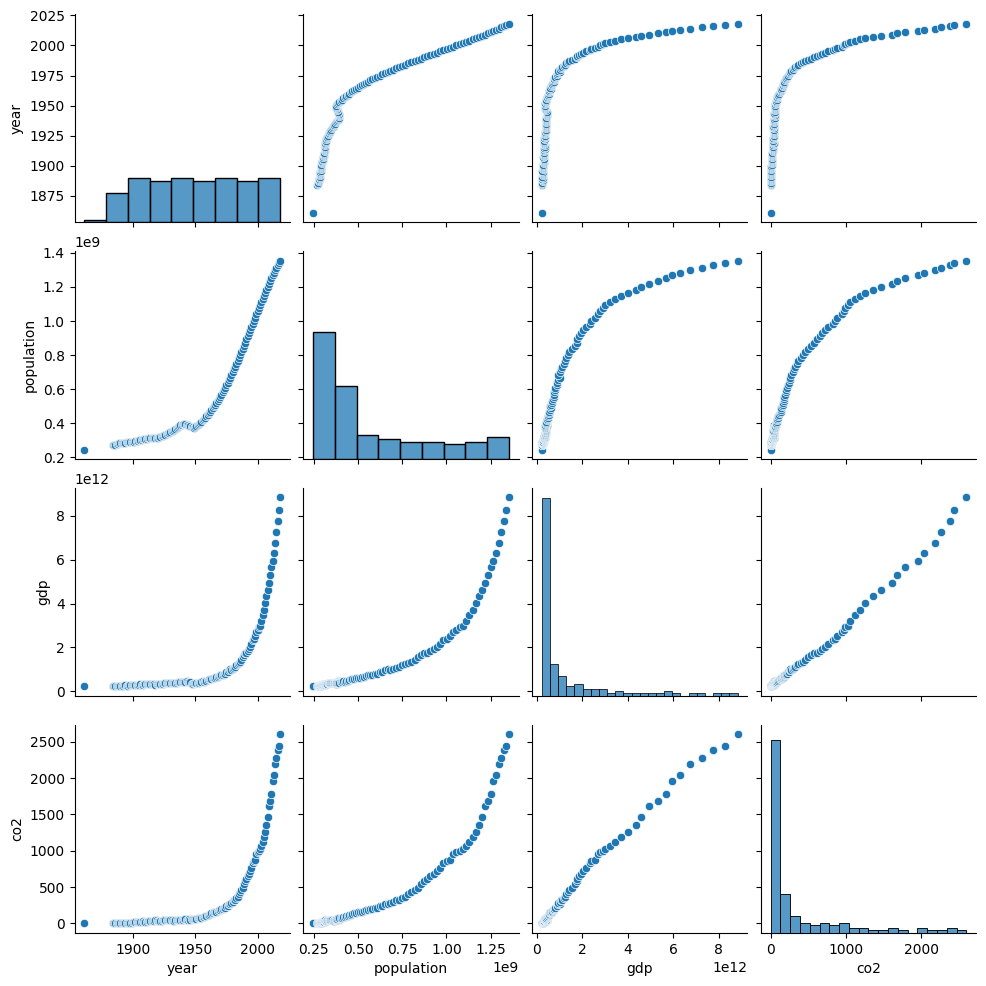

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df_model)
plt.show()

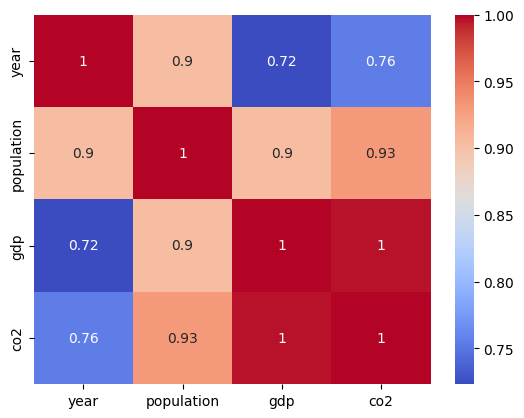

In [10]:
sns.heatmap(df_model.corr(), annot=True, cmap="coolwarm")
plt.show()

In [11]:
X = df_model[["year", "population", "gdp"]]
y = df_model["co2"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [16]:
y_pred = model.predict(X_test_scaled)

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 9.482198571428617
RMSE: 21.525600942541857
R2 Score: 0.998717972146675


In [18]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']